In [5]:
import random
from collections import deque, namedtuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import HTML
from matplotlib import animation

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Python refresher: subclassing `nn.Module`
Every PyTorch network is a class that inherits from `nn.Module` and defines a `forward()` method describing how input data flows through it. This is the same "class with methods" pattern you'd use for any custom Python object; PyTorch just expects specific method names (`__init__` and `forward`) so it knows how to run and train the network.

In [6]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer: 
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch)) # transpose list of tuples into tuples of lists

    def __len__(self):
        return len(self.buffer)

In [8]:
class DQNAgent:
    def __init__(self, obs_dim, n_actions, hidden_size=128, lr=1e-3, gamma=0.99,
                 buffer_capacity=50000, batch_size=64):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size

        self.q_network = QNetwork(obs_dim, n_actions, hidden_size)
        self.target_network = QNetwork(obs_dim, n_actions, hidden_size)
        self.sync_target()
        self.target_network.eval()  # target network is never trained directly

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)

    def sync_target(self):
        """Copy the Q-network's weights into the target network."""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.n_actions)  # explore
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.q_network(state_t)
        return int(torch.argmax(q_values, dim=1).item())  # exploit

    def store(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return None # not enough experience yet

        batch = self.buffer.sample(self.batch_size)

        states = torch.as_tensor(np.array(batch.state), dtype=torch.float32)
        actions = torch.as_tensor(batch.action, dtype=torch.int64).unsqueeze(1)
        rewards = torch.as_tensor(batch.reward, dtype=torch.float32).unsqueeze(1)
        next_states = torch.as_tensor(np.array(batch.next_state), dtype=torch.float32)
        dones = torch.as_tensor(batch.done, dtype=torch.float32).unsqueeze(1)

        # Q-values the network currently predicts for the actions actually taken
        q_values = self.q_network(states).gather(1, actions)

        # Q-learning target, using the target network for stability
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1, keepdim=True)[0]
            td_target = rewards + self.gamma * next_q_values * (1.0 - dones)

        loss = nn.functional.mse_loss(q_values, td_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

## The Training Loop
Structurally similar to the tabular notebook's training loop: reset, act, step, learn, repeat. Two differences:
- No `discretize()` call - the raw observation goes straight into the network.
- A `target_update_freq` - every this-many episodes, we sync the target network.

We wrap this in a function so we can call it repeatedly during the sweep, each time with a fresh agent and a fresh environment.


In [11]:
def moving_average(x, window=20):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)


def train_dqn(agent, episodes=200, max_steps=500, epsilon_start=1.0, epsilon_min=0.05,
              epsilon_decay=0.995, target_update_freq=10, seed=None, verbose_every=None):
    env = gym.make("Acrobot-v1")
    epsilon = epsilon_start
    episode_rewards = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed if ep == 0 else None)
        total_reward = 0

        for t in range(max_steps):
            action = agent.select_action(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store(obs, action, reward, next_obs, done)
            agent.train_step()

            obs = next_obs
            total_reward += reward
            if done:
                break

        episode_rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % target_update_freq == 0:
            agent.sync_target()

        if verbose_every and (ep + 1) % verbose_every == 0:
            recent_avg = np.mean(episode_rewards[-verbose_every:])
            print(f"  Episode {ep + 1}/{episodes} | epsilon={epsilon:.3f} | avg reward (last {verbose_every}): {recent_avg:.1f}")

    env.close()
    return episode_rewards


Observation dimension: 6, number of actions: 3
  Episode 20/100 | epsilon=0.905 | avg reward (last 20): -500.0
  Episode 40/100 | epsilon=0.818 | avg reward (last 20): -500.0
  Episode 60/100 | epsilon=0.740 | avg reward (last 20): -500.0
  Episode 80/100 | epsilon=0.670 | avg reward (last 20): -479.9
  Episode 100/100 | epsilon=0.606 | avg reward (last 20): -482.9


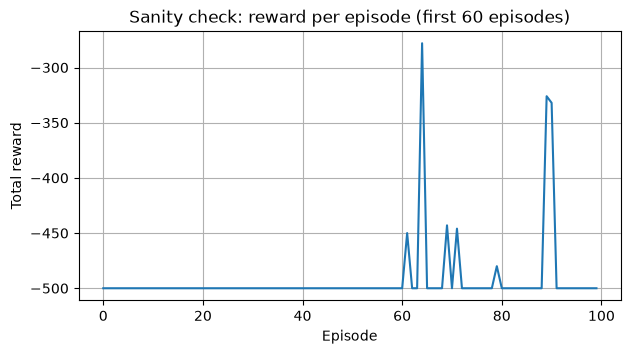

In [13]:
_env = gym.make("Acrobot-v1")
OBS_DIM = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
_env.close()

print(f"Observation dimension: {OBS_DIM}, number of actions: {N_ACTIONS}")

torch.manual_seed(SEED)
sanity_agent = DQNAgent(obs_dim=OBS_DIM, n_actions=N_ACTIONS)
sanity_rewards = train_dqn(sanity_agent, episodes=100, seed=SEED, verbose_every=20)

plt.figure(figsize=(7, 3.5))
plt.plot(sanity_rewards)
plt.title("Sanity check: reward per episode (first 60 episodes)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.grid(True)
plt.show()

In [21]:
SWEEP_EPISODES = 200

sweep_configs = [
    {"lr": 1e-3, "gamma": 0.99},
    {"lr": 1e-3, "gamma": 0.95},
    {"lr": 5e-4, "gamma": 0.99},
    {"lr": 5e-4, "gamma": 0.95},
]

sweep_results = []

for cfg in sweep_configs:
    label = f"lr={cfg["lr"]}, gamma={cfg["gamma"]}"
    print(f"Training config: {label}")

    torch.manual_seed(SEED)
    agent = DQNAgent(obs_dim=OBS_DIM, n_actions=N_ACTIONS, lr=cfg["lr"], gamma=cfg["gamma"])
    rewards = train_dqn(agent, episodes=SWEEP_EPISODES, seed=SEED, verbose_every=50)

    sweep_results.append({"label" : label, "cfg": cfg, "rewards": rewards})
    print()

Training config: lr=0.001, gamma=0.99
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -493.1
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -485.4
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -462.6
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -363.1

Training config: lr=0.001, gamma=0.95
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -499.1
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -485.9
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -418.0
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -384.3

Training config: lr=0.0005, gamma=0.99
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -498.9
  Episode 100/200 | epsilon=0.606 | avg reward (last 50): -492.1
  Episode 150/200 | epsilon=0.471 | avg reward (last 50): -445.0
  Episode 200/200 | epsilon=0.367 | avg reward (last 50): -451.1

Training config: lr=0.0005, gamma=0.95
  Episode 50/200 | epsilon=0.778 | avg reward (last 50): -500.0
  

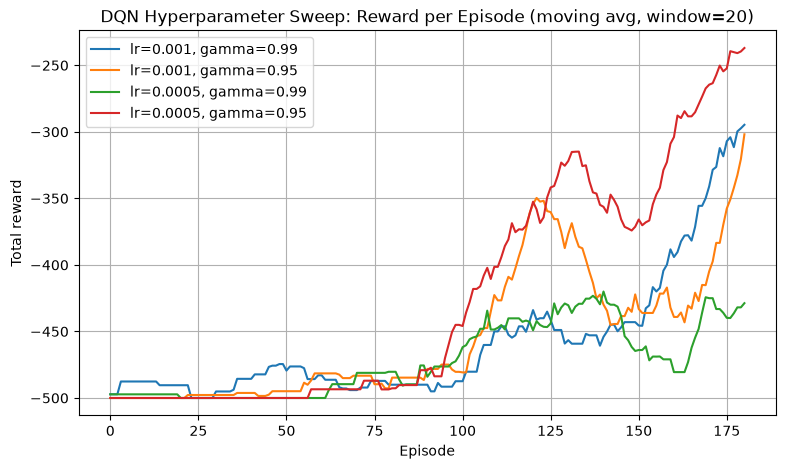

Final performance (average of last 20 episodes) per config:
  lr=0.001, gamma=0.99: -294.7
  lr=0.001, gamma=0.95: -301.9
  lr=0.0005, gamma=0.99: -428.8
  lr=0.0005, gamma=0.95: -237.0


In [23]:
plt.figure(figsize=(9, 5))
for result in sweep_results:
    smoothed = moving_average(result["rewards"], window=20)
    plt.plot(smoothed, label=result["label"])
plt.title("DQN Hyperparameter Sweep: Reward per Episode (moving avg, window=20)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.grid(True)
plt.show()

print("Final performance (average of last 20 episodes) per config:")
for result in sweep_results:
    final_avg = np.mean(result["rewards"][-20:])
    print(f"  {result['label']}: {final_avg:.1f}")